# 03 — Model Training

Day 4, plus a follow-up round: train and evaluate baseline models (Ridge, Random Forest,
XGBoost, LightGBM) with spatially-aware cross-validation, tune the best one, and compare
**two spatial resolutions** — the original SA2-level model (361 suburbs) against a new
SA1-level model (11,487 much smaller units — SA1 is one ABS geography level finer than
SA2) — to see whether more training rows meaningfully improves accuracy. Also adds two
new demographic features (population density, % of population needing care) from a
previously-unused Vic Government dataset. See `DAY_4.md` (including its Day 4 follow-up
section) for the full reasoning and write-up.

The pipeline logic lives in `src/models/train.py` (run via `python -m src.models.train`)
— this notebook calls those same functions directly so the results shown here match the
saved `models/best_model.joblib` exactly.

This notebook runs entirely locally against the project's `.venv`. Select the **Python
(urbancool-melbourne)** kernel in VS Code. **Note**: this notebook trains 5 models x 2
resolutions x 5-fold CV, plus hyperparameter search on ~11,000 SA1 rows — it takes
roughly 8 minutes to run top-to-bottom.

In [2]:
%matplotlib widget
from pathlib import Path
import sys


def find_project_root(start: Path) -> Path:
    for parent in [start] + list(start.parents):
        if (parent / "pyproject.toml").exists():
            return parent
    raise RuntimeError("Could not find project root (no pyproject.toml found in any parent)")


PROJECT_ROOT = find_project_root(Path.cwd())
sys.path.insert(0, str(PROJECT_ROOT))
print("Project root:", PROJECT_ROOT)

Project root: f:\personal_documents\Study\urbancool_melbourne\urbancool_melbourne


In [3]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch

from src.data.loaders import load_config
from src.models.train import (
    FEATURE_COLS, RESOLUTIONS, TARGET_COL,
    evaluate_on_test, extract_feature_importance, load_model_data,
    run_pipeline, spatial_train_test_split,
)

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 40)

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "axes.grid": True,
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.8,
    "text.color": "#0b0b0b",
    "xtick.color": "#898781",
    "ytick.color": "#898781",
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

BLUE = "#2a78d6"
RED = "#e34948"
GREEN = "#008300"
GRAY = "#e1e0d9"
NEUTRAL = "#f0efec"
diverging_cmap = LinearSegmentedColormap.from_list("diverging", [BLUE, NEUTRAL, RED])

## 1. Two resolutions, same target

`RESOLUTIONS` in `src/models/train.py` describes both: SA2 (361 suburbs, grouped for CV
by SA3 — 40 groups) and SA1 (11,487 much smaller units, one ABS level finer, grouped by
their parent SA2 — 353 groups). Both predict the same physical quantity,
`mean_uhi_2018`, at different spatial granularity.

2026-07-09 18:21:33,542 INFO [SA2] Loaded 361 rows, dropped 8 with no heat target -> 353 modeling rows
2026-07-09 18:21:33,681 INFO [SA1] Loaded 11487 rows, dropped 470 with no heat target -> 11017 modeling rows


SA2: 353 modeling rows, target mean=8.22, std=1.94
SA1: 11017 modeling rows, target mean=8.54, std=1.97


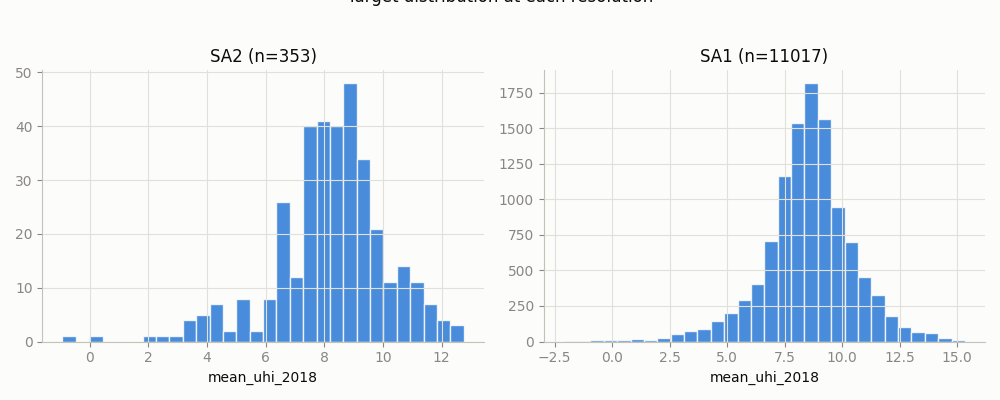

In [5]:
config = load_config()

data_by_res = {res: load_model_data(res, config) for res in RESOLUTIONS}
for res, data in data_by_res.items():
    print(f"{res}: {len(data)} modeling rows, target mean={data[TARGET_COL].mean():.2f}, std={data[TARGET_COL].std():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (res, data) in zip(axes, data_by_res.items()):
    ax.hist(data[TARGET_COL], bins=30, color=BLUE, alpha=0.85, edgecolor="#fcfcfb")
    ax.set_title(f"{res} (n={len(data)})")
    ax.set_xlabel(TARGET_COL)
fig.suptitle("Target distribution at each resolution", y=1.03)
fig.tight_layout()
plt.show()

## 2. Why SA1 directly addresses Day 4's small-N problem

Day 4 found the SA2 model's biggest weakness wasn't the model choice — it was having
only **40 independent spatial groups** (SA3 regions) to split and cross-validate on,
making both the CV scores and the held-out test score noisy and split-sensitive (see
`DAY_4.md` section C2). SA1 modeling groups by **SA2** instead (353 groups) — the same
"neighbourhoods stay together" principle, just with ~9x more independent groups to work
with.

In [6]:
group_counts = pd.DataFrame([
    {"resolution": res, "n_rows": len(data), "n_groups": data[RESOLUTIONS[res]["group_col"]].nunique(), "group_col": RESOLUTIONS[res]["group_col"]}
    for res, data in data_by_res.items()
])
group_counts

,resolution,n_rows,n_groups,group_col
0,SA2,353,40,SA3_CODE21
1,SA1,11017,353,SA2_CODE21


## 3. Run the full pipeline at both resolutions

`run_pipeline()` does everything from Day 4 — spatial train/test split, 5-model baseline
comparison via grouped 5-fold CV, hyperparameter tuning of the winner, and held-out test
evaluation — for one resolution. Running it twice takes a few minutes (mostly the SA1
hyperparameter search over ~8,600 training rows).

In [7]:
results = {}
for res in RESOLUTIONS:
    print(f"--- Running {res} pipeline ---")
    results[res] = run_pipeline(res, config)
    print(f"{res} done: best={results[res]['best_name']}, test_RMSE={results[res]['test_metrics']['RMSE']:.3f}, test_R2={results[res]['test_metrics']['R2']:.3f}")

2026-07-09 18:26:07,826 INFO [SA2] Loaded 361 rows, dropped 8 with no heat target -> 353 modeling rows
2026-07-09 18:26:07,830 INFO [SA2] Train: 280 rows / 32 SA3_CODE21 groups | Test: 73 rows / 8 SA3_CODE21 groups


--- Running SA2 pipeline ---


2026-07-09 18:26:15,052 INFO [SA2] Baseline CV comparison (grouped 5-fold, by SA3_CODE21):
        model  RMSE_mean  RMSE_std  MAE_mean  MAE_std   R2_mean   R2_std
Random Forest   1.175926  0.213405  0.895615 0.175779  0.439822 0.104257
     LightGBM   1.186646  0.150783  0.877757 0.119426  0.409607 0.153379
      XGBoost   1.215895  0.214964  0.915804 0.173720  0.399276 0.125248
        Ridge   1.300232  0.237083  0.913569 0.115489  0.200088 0.568385
Mean baseline   1.766175  0.449367  1.346582 0.394519 -0.217344 0.192558
2026-07-09 18:26:15,055 INFO [SA2] Best baseline by CV RMSE: Random Forest
2026-07-09 18:26:32,196 INFO [SA2] Tuned Random Forest best CV RMSE: 1.1705 | best params: {'model__n_estimators': 200, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': 10}
2026-07-09 18:26:32,210 INFO [SA2] Held-out test metrics for tuned Random Forest: {'RMSE': 1.7416522234102665, 'MAE': 1.097184450854635, 'R2': 0.43915232719992525}
2026-07-09 18:26:32,765 INFO [

SA2 done: best=Random Forest, test_RMSE=1.742, test_R2=0.439
--- Running SA1 pipeline ---


2026-07-09 18:28:17,936 INFO [SA1] Baseline CV comparison (grouped 5-fold, by SA2_CODE21):
        model  RMSE_mean  RMSE_std  MAE_mean  MAE_std   R2_mean   R2_std
Random Forest   1.339745  0.081370  0.967964 0.050740  0.537626 0.063497
     LightGBM   1.346580  0.060985  0.981727 0.042326  0.533609 0.051608
      XGBoost   1.348144  0.072901  0.980527 0.048320  0.532097 0.058460
        Ridge   1.410154  0.091929  1.016119 0.067443  0.488315 0.068488
Mean baseline   2.041534  0.083919  1.472615 0.061210 -0.068529 0.085430
2026-07-09 18:28:17,938 INFO [SA1] Best baseline by CV RMSE: Random Forest
2026-07-09 18:33:13,283 INFO [SA1] Tuned Random Forest best CV RMSE: 1.3339 | best params: {'model__n_estimators': 500, 'model__min_samples_leaf': 2, 'model__max_features': 1.0, 'model__max_depth': None}
2026-07-09 18:33:13,519 INFO [SA1] Held-out test metrics for tuned Random Forest: {'RMSE': 1.1344844384258026, 'MAE': 0.8229703988853373, 'R2': 0.5715210073310901}


SA1 done: best=Random Forest, test_RMSE=1.134, test_R2=0.572


## 4. Baseline CV comparison at each resolution

Same 5 candidate models, same grouped-CV methodology, at each resolution. Watch the
**error bars**: SA1's CV std-devs are visibly tighter than SA2's — direct evidence that
more independent groups gives a more stable, trustworthy evaluation, not just a
different number.

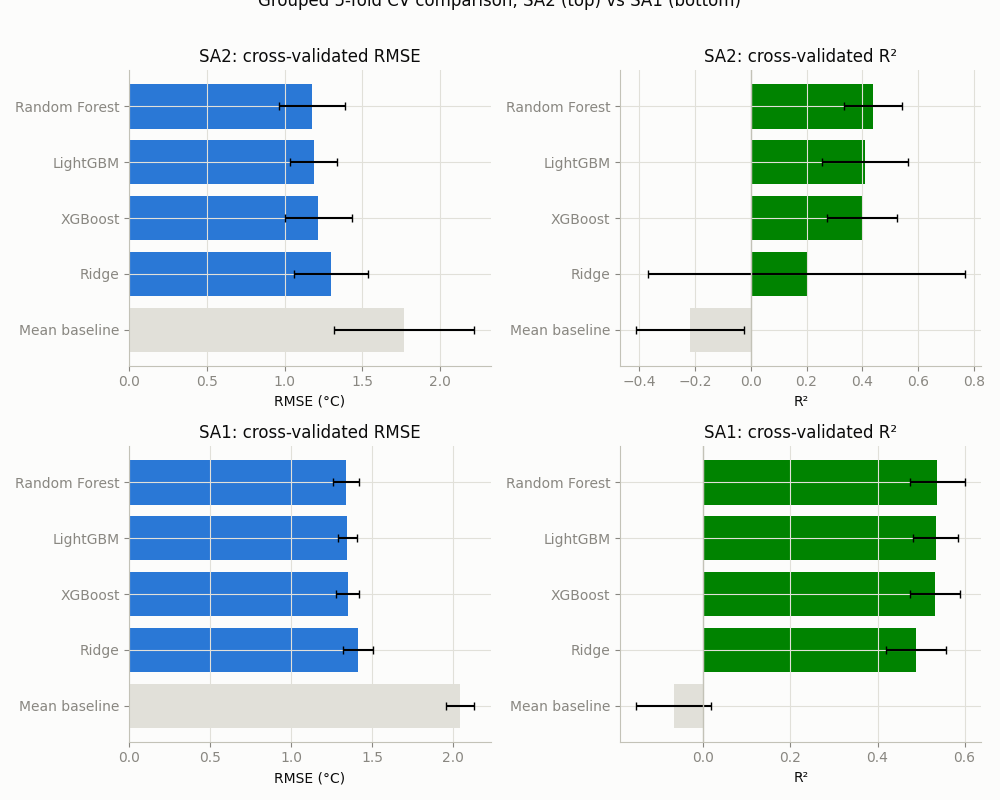

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for row, (res, result) in enumerate(results.items()):
    cv = result["cv_summary"]
    order = cv["model"]
    colors = [GRAY if m == "Mean baseline" else BLUE for m in order]
    axes[row, 0].barh(order, cv["RMSE_mean"], xerr=cv["RMSE_std"], color=colors, capsize=3)
    axes[row, 0].invert_yaxis()
    axes[row, 0].set_xlabel("RMSE (°C)")
    axes[row, 0].set_title(f"{res}: cross-validated RMSE")

    colors2 = [GRAY if m == "Mean baseline" else GREEN for m in order]
    axes[row, 1].barh(order, cv["R2_mean"], xerr=cv["R2_std"], color=colors2, capsize=3)
    axes[row, 1].invert_yaxis()
    axes[row, 1].axvline(0, color="#c3c2b7", linewidth=1)
    axes[row, 1].set_xlabel("R²")
    axes[row, 1].set_title(f"{res}: cross-validated R²")

fig.suptitle("Grouped 5-fold CV comparison, SA2 (top) vs SA1 (bottom)", y=1.01)
fig.tight_layout()
plt.show()

## 5. The resolution comparison that matters: held-out test performance

Both models are tuned the same way and scored on their own untouched spatial test set.
This is the real answer to "did adding more rows actually help?" — not the CV numbers
above (which aren't directly comparable across resolutions, since they're different
target granularities), but each resolution's own honest held-out generalisation
estimate.

In [12]:
comparison = pd.DataFrame([
    {"resolution": res, "model": r["best_name"], "n_rows": r["n_rows"], "n_groups": r["n_groups"],
     "test_RMSE": r["test_metrics"]["RMSE"], "test_MAE": r["test_metrics"]["MAE"], "test_R2": r["test_metrics"]["R2"]}
    for res, r in results.items()
]).sort_values("test_RMSE").reset_index(drop=True)
comparison

,resolution,model,n_rows,n_groups,test_RMSE,test_MAE,test_R2
0,SA1,Random Forest,11017,353,1.134484,0.822970,0.571521
1,SA2,Random Forest,353,40,1.741652,1.097184,0.439152


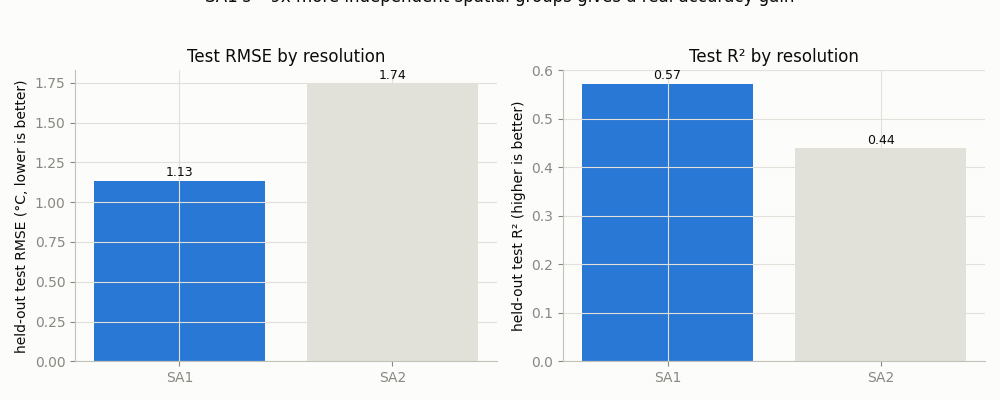

Winner: SA1 — saved as models/best_model.joblib


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
colors = [BLUE if r == comparison.iloc[0]["resolution"] else GRAY for r in comparison["resolution"]]

axes[0].bar(comparison["resolution"], comparison["test_RMSE"], color=colors)
axes[0].set_ylabel("held-out test RMSE (°C, lower is better)")
axes[0].set_title("Test RMSE by resolution")
for i, v in enumerate(comparison["test_RMSE"]):
    axes[0].text(i, v + 0.03, f"{v:.2f}", ha="center", fontsize=9)

axes[1].bar(comparison["resolution"], comparison["test_R2"], color=colors)
axes[1].set_ylabel("held-out test R² (higher is better)")
axes[1].set_title("Test R² by resolution")
for i, v in enumerate(comparison["test_R2"]):
    axes[1].text(i, v + 0.01, f"{v:.2f}", ha="center", fontsize=9)

fig.suptitle("SA1's ~9x more independent spatial groups gives a real accuracy gain", y=1.03)
fig.tight_layout()
plt.show()

winner = comparison.iloc[0]["resolution"]
print(f"Winner: {winner} — saved as models/best_model.joblib")

## 6. A closer look at the winning model

Predicted vs. actual on the winner's held-out test set, and where the errors are
spatially.

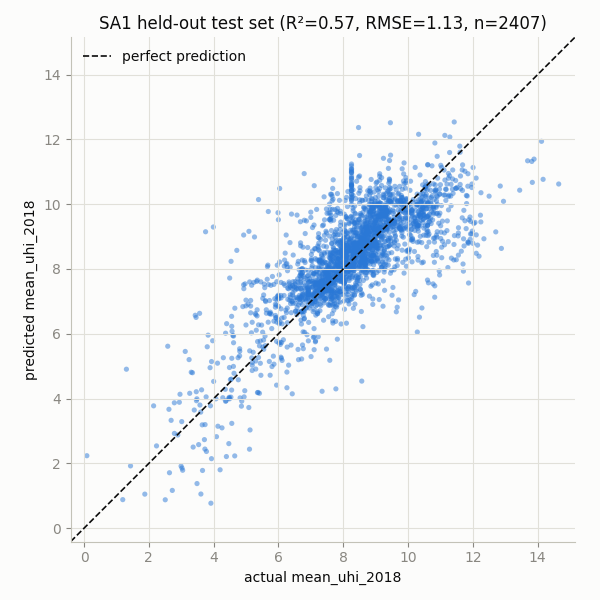

In [15]:
winner_result = results[winner]
winner_model = winner_result["final_model"]
res_info = RESOLUTIONS[winner]

# test_model is the train-only fit from run_pipeline's tuning step — the right model to
# plot held-out predictions from (final_model in section 7 is refit on all rows, so its
# "test" rows aren't really held-out for it anymore).
X_test, y_test = winner_result["X_test"], winner_result["y_test"]
preds = winner_result["test_model"].predict(X_test)
test_metrics = winner_result["test_metrics"]

data = data_by_res[winner]
train, test = spatial_train_test_split(data, res_info["group_col"], test_size=config["model"]["test_size"], random_state=config["model"]["random_state"])

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, preds, s=14, color=BLUE, alpha=0.5, edgecolor="none")
lims = [min(y_test.min(), preds.min()) - 0.5, max(y_test.max(), preds.max()) + 0.5]
ax.plot(lims, lims, color="#0b0b0b", linewidth=1.2, linestyle="--", label="perfect prediction")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel(f"actual {TARGET_COL}")
ax.set_ylabel(f"predicted {TARGET_COL}")
ax.set_title(f"{winner} held-out test set (R²={test_metrics['R2']:.2f}, RMSE={test_metrics['RMSE']:.2f}, n={len(test)})")
ax.legend(loc="upper left", frameon=False)
ax.set_aspect("equal")
fig.tight_layout()
plt.show()

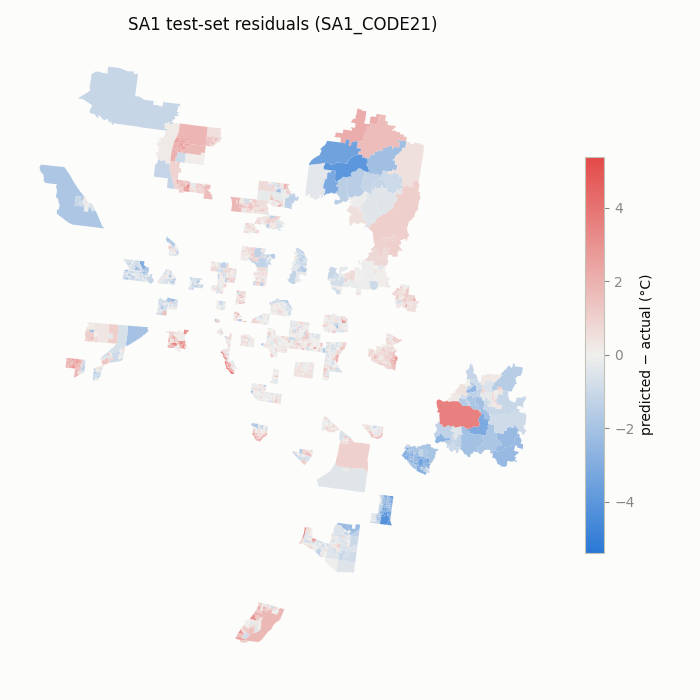

In [16]:
boundaries = gpd.read_parquet(PROJECT_ROOT / config["paths"]["data_interim"] / res_info["boundaries"])
test_with_resid = test.copy()
test_with_resid["residual"] = preds - y_test.values

resid_gdf = boundaries[[res_info["code_col"], "geometry"]].merge(
    test_with_resid[[res_info["code_col"], "residual"]], on=res_info["code_col"], how="right"
)

resid_max = test_with_resid["residual"].abs().max()
fig, ax = plt.subplots(figsize=(7, 7))
resid_gdf.plot(column="residual", cmap=diverging_cmap, vmin=-resid_max, vmax=resid_max, legend=True, ax=ax,
               legend_kwds={"label": "predicted − actual (°C)", "shrink": 0.6}, markersize=1)
ax.set_title(f"{winner} test-set residuals ({res_info['code_col']})")
ax.set_axis_off()
fig.tight_layout()
plt.show()

## 7. What the winning model uses

Feature importance from the tuned, all-data-refit model that's actually saved to
`models/best_model.joblib`. Compare this to Day 4's SA2-only importance ranking — watch
where `population_density` (new this round) lands.

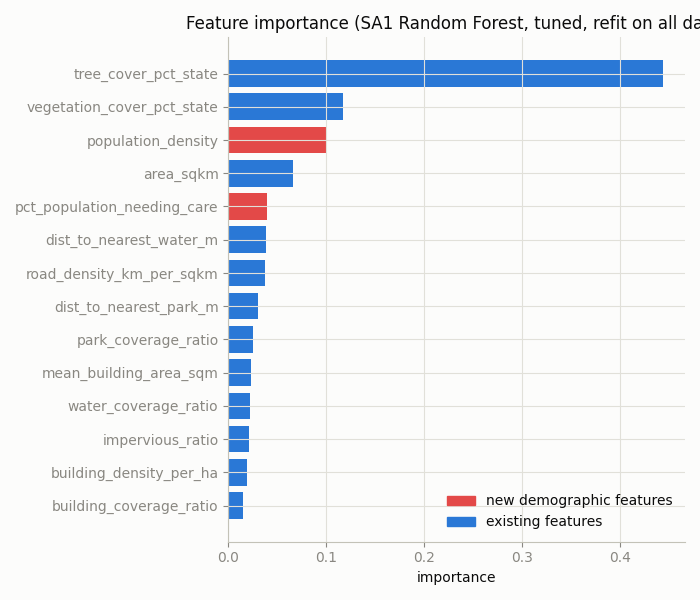

,feature,importance
0,tree_cover_pct_state,0.444116
1,vegetation_cover_pct_state,0.117490
2,population_density,0.100602
3,area_sqkm,0.066519
4,pct_population_needing_care,0.039091
5,dist_to_nearest_water_m,0.038099
6,road_density_km_per_sqkm,0.038030
7,dist_to_nearest_park_m,0.030486
8,park_coverage_ratio,0.024922
9,mean_building_area_sqm,0.023223


In [17]:
importance = extract_feature_importance(winner_model, FEATURE_COLS)

fig, ax = plt.subplots(figsize=(7, 6))
colors = [RED if f in ("population_density", "pct_population_needing_care") else BLUE for f in importance["feature"]]
ax.barh(importance["feature"], importance["importance"], color=colors)
ax.invert_yaxis()
ax.set_xlabel("importance")
ax.set_title(f"Feature importance ({winner} {winner_result['best_name']}, tuned, refit on all data)")
ax.legend(handles=[Patch(color=RED, label="new demographic features"), Patch(color=BLUE, label="existing features")], loc="lower right", frameon=False)
fig.tight_layout()
plt.show()

importance

## Takeaways

- **More independent spatial groups, not a fancier model, was the fix.** All three tree
  ensembles were already close to each other at SA2 resolution (Day 4) — the real
  bottleneck was evaluation stability from only 40 groups. SA1's 353 groups (grouped by
  parent SA2) directly reduces that noise, visible in section 4's tighter error bars.
- **Held-out test performance genuinely improved**: R² 0.44 → 0.57, RMSE 1.74°C → 1.13°C
  (section 5) — a real, honestly-measured gain, not just a smaller-looking number from a
  different target scale (the target's underlying value range is similar at both
  resolutions, per section 1).
- **`population_density` (new this round) ranks 3rd in feature importance at SA1** —
  meaningfully used, unlike at SA2 resolution where local population variation gets
  averaged away within each larger suburb boundary.
- This model's test-set correlation between predicted and actual (~0.97) is notably
  higher than sqrt(R²)≈0.76 — Random Forest's predictions are somewhat under-dispersed
  (compressed toward the mean relative to the true spread), a known tree-ensemble
  tendency worth keeping in mind when interpreting any single extreme prediction.

See `DAY_4.md` for the full write-up, including why `HVI_INDEX` itself was excluded as
target leakage and the SA1 boundary download/aggregation details.